# 什么是 Diffusion Policy

一种新型机器人行为生成方法，将图像生成领域的 Diffusion Model 应用到机器人连续动作控制上。

将机器人的视觉动作策略表示为条件去噪扩散过程（<mark>训练时加噪（预测被加入的噪声），推理时去噪</mark>）。

# 解决的问题

## 生成领域的多峰问题（Multi-modal）

多峰问题：问题不只有唯一的最佳答案，而是存在多个合理但截然不同的“峰值”。

传统的回归模型（如使用均方误差 MSE 损失函数的神经网络）或非自回归生成模型，在面对多峰分布时，往往会尝试去“拟合所有可能性”，其结果就是取平均值，试图最小化与数据之间的距离。

在图像生成或文本生成中，这种“取平均”会导致输出结果模糊、缺乏细节或逻辑冲突。

解决方法：引入概率分布，让机器人有机会在相同的情况下选择不同的行为，从而避免陷入不可预测的循环。

## 动作空间可扩展性（Action Space Scalability）

动作空间可扩展性：当机器人的动作维度（如关节自由度）增加，或需要预测更长未来时间序列（多步动作）时，算法能否保持高效、稳定，且不出现计算复杂度爆炸的能力。

- 维度灾难：如果使用离散化方法预测动作，那么每增加一个自由度，计算量就会指数级增加。


### 解决方法

#### 动作分块生成

在一次生成过程中，直接输出未来一段连续的动作序列。

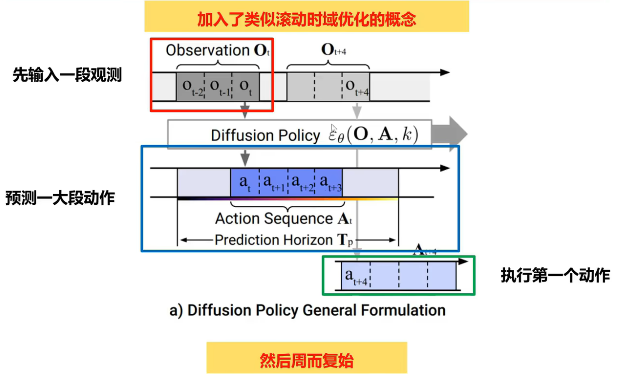

保证了时间维度上的连贯性，避免维度灾难。

#### 将高维预测转化为“迭代去噪”

传统的分类方法在高维连续空间中会面临组合爆炸，而扩散模型不对动作空间进行硬性离散化切分。

通过前向加噪和反向去噪的迭代过程，模型学习的是这个高维空间的概率分布梯度场（Score Function）。

无论动作维度多高，神经网络（如 U-Net 或 Transformer）只需在相同的迭代步骤中逐步“精炼”（refine）这个高维张量，计算复杂度随维度呈多项式增长，而非指数级爆炸 


## 训练稳定性问题

Diffusion（扩散模型）之所以被公认为具有极高的训练稳定性，核心在于它将复杂的生成任务，转化为了一个“单一、平滑且无对抗”的回归问题。主要原因：

1. Diffusion 的训练目标极其纯粹且统一——<mark>预测噪声（Noise Prediction）</mark>。

在每一步训练中，模型只需要计算它预测的噪声 $\epsilon_\theta$ 与真实添加的高斯噪声 $\epsilon$ 之间的均方误差（MSE）或 Huber Loss。

$$Loss = \mathbb{E}\left[\left\|\epsilon - \epsilon_\theta(x_t, t)\right\|^2\right]$$

这是一个标准的、凸性良好的回归目标。没有对抗博弈，没有复杂的权重平衡，优化器（如 AdamW）可以非常顺畅地沿着梯度下降，大大降低了训练发散的风险。

2. 在前向扩散过程中，数据被逐步注入了<mark>高斯噪声</mark>。高斯噪声在数学上等价于对数据分布进行“卷积平滑”。

这意味着，在训练时，模型看到的不再是尖锐、稀疏的数据点，而是被噪声“涂抹”过的、平滑的概率分布。平滑的损失地形使得梯度更加稳定、可预测，模型能够稳健地收敛，而不会在训练初期就因为梯度爆炸而崩溃。

3. 解耦了“多模态建模”与“模型优化”

- 在训练阶段：模型不需要去“决定”最终输出哪个峰，它只需要学习整个数据分布的梯度场（Score Function）。拟合一个平滑的向量场，比直接拟合多峰的具体数值要容易得多、稳定得多。

- 在推理（采样）阶段：通过引入随机噪声（Langevin Dynamics），让生成过程自然坍缩到某一个峰上。

    这种“训练时学全局规律，采样时做随机选择”的机制，让训练过程避开了多峰数据带来的优化陷阱。

# Reference

[1] Diffusion Policy—基于扩散模型的机器人动作生成策略 - 王建明的文章 - 知乎
https://zhuanlan.zhihu.com/p/670555655

[2] 最适合入门的diffusion policy https://www.bilibili.com/video/BV1MtXHYUE6M